# **1. Seq2Seq**
시퀀스투시퀀스(Sequence-to-Sequence, Seq2Seq) 모델은 입력 시퀀스를 받아 출력 시퀀스를 생성하는 신경망 아키텍처로, 
<br>주로 자연어 처리 분야에서 번역, 요약, 질의응답 등에 활용됩니다. 
<br>Seq2Seq 모델은 일반적으로 인코더(Encoder)와 디코더(Decoder) 두 부분으로 구성되며, 
<br>인코더는 입력 문장을 고정된 크기의 컨텍스트 벡터로 변환하고, 디코더는 이를 기반으로 출력 문장을 생성합니다. 
<br>RNN, LSTM, GRU 등의 순환 신경망을 활용하며, 
<br>최근에는 어텐션 메커니즘과 트랜스포머 모델이 도입되어 더 긴 문맥을 효과적으로 처리할 수 있게 되었습니다.
<br>[[논문](https://arxiv.org/abs/1409.3215)]
https://arxiv.org/pdf/1409.3215

이건 트랜스포머
https://arxiv.org/abs/1706.03762
<br>꼭 봤으면 하는 논문 2개

- Seq2Seq는 입력 시퀀스를 받아 다른 출력 시퀀스로 바꾸는 구조
- 대표적인 예는 기계 번역
    - I love coffee > 나는 커피를 좋아해
    - I love coffee > Encoder > 문장 정보 압축 > Decoder > \<BOS\> 나는 / 커피를 / 좋아해 \<EOS\> (EOS는 끝났다는 걸 의미)
    - \<BOS\>: 문장 생성을 시작한다는 특별 토큰
    - \<EOS\>: 문장이 끝났다는 특별 토큰
    - Decoder는 이전에 생성한 토큰을 이용해 다음 토큰을 예측
- 고전적인 Seq2Seq는 보통 Encoder + Decoder로 구성되며, RNN/LSTM/GRU 등을 사용
    - Encoder: 입력을 순서대로 읽으며 hidden state에 정보를 누적
    - Decoder: Encoder가 만든 정보를 바탕으로 출력 토큰을 한 개씩 생성. 이전에 생성한 토큰을 이용해 다음 토큰을 예측. Autogressive(자기회귀)

![Seq2Seq](./images/Seq2Seq.png)

### Seq2Seq의 문제점
- 초기 Seq2Seq는 Encoder의 마지막 hidden state 하나를 Decoder에 전달하는 방식이 많이 사용되었음
- 짧은 문장이라면 괜찮지만 문장이 길어지면 마지막 hidden state 하나가 앞부분의 세부 정보까지 모두 기억해야 함. 이처럼 많은 정보를 제한된 하나의 표현에 압축하면서 중요한 정보가 손실될 수 있음(정보 병목, Bottleneck)

- RNN은 t 시점 계산 > t + 1 시점 게산처럼 앞 계산이 끝나야 다음 계산을 할 수 있으므로 긴 문장에서 학습이 느리고 병렬 처리에도 불리

 # **2. Attention 메커니즘**
- Attention은 현재 토큰이 다른 토큰들을 얼마나 참고할지 점수로 계산하는 방법
- 점수를 Softmax로 바꾸면 각 토큰을 섞는 Attention Weight가 됨
- Transformer의 Self-Attention에서는 문장 안의 모든 토큰이 서로의 관게를 직접 계산할 수 있음

```
예를들어 "나는 오늘 학교에서 수학 시험을 봤다" 에서 어떤 토큰을 해석할 때 항상 시험만 중요한 것은 아님. 
어떤 토큰을 처리하느냐와 학습된 관계에 따라 중요한 대상이 달라짐.
```

### 1. 토큰을 숫자 벡터로 바꾸기
- 신경망은 "커피 한잔 어때" 같은 문자열을 그대로 계산할 수 없음
- 문장 > Token > Token ID > Emnedding Layer > Embedding Vector
    - 커피: 0
    - 한잔: 1
    - 어때: 2
    - 0, 1, 2 자체는 의미가 없음. 단엉를 찾기 위한 번호일 뿐.
    - nn.Embedding이 번호를 학습 가능한 실수 벡터로 바꿈

In [1]:
import torch
import torch.nn as nn

torch.manual_seed(2026)

token = ['커피', '한잔', '어때']
token_ids = torch.tensor([0, 1, 2])
print('토큰: ', token)
print('토큰 ID: ', token_ids)
print('토큰 ID shape: ', token_ids.shape)

토큰:  ['커피', '한잔', '어때']
토큰 ID:  tensor([0, 1, 2])
토큰 ID shape:  torch.Size([3])


### 2. nn.Embedding
- nn.Emnedding(num_embedding = 3, embedding_dim = 4)는 3행 * 4열의 학습 가능한 표

```
TokenI ID 0(커피) > [실수, 실수, 실수, 실수]
TokenI ID 1(한잔) > [실수, 실수, 실수, 실수]
TokenI ID 2(어때) > [실수, 실수, 실수, 실수]
```
- num_embeddings = 3: 사용할 수 있는 Token ID의 개수
- embedding_dim = 4: 토큰 하나를 표현하는 숫자의 개수
- embedding.weight.shape == (3, 4)

In [2]:
embedding = nn.Embedding(num_embeddings=3, embedding_dim=4)
print(embedding)
print(embedding.weight)

Embedding(3, 4)
Parameter containing:
tensor([[ 0.3655,  1.9065,  0.2169,  0.2963],
        [-1.0160, -0.6064,  0.1744, -0.6306],
        [-0.0954,  0.3191, -1.4710,  0.2610]], requires_grad=True)


In [3]:
X = embedding(token_ids)
print("임베딩 결과 X: ", X)
print("shape: ", X.shape)
print('토큰 수: ', X.shape[0])
print('임베딩 차원: ', X.shape[1])

임베딩 결과 X:  tensor([[ 0.3655,  1.9065,  0.2169,  0.2963],
        [-1.0160, -0.6064,  0.1744, -0.6306],
        [-0.0954,  0.3191, -1.4710,  0.2610]], grad_fn=<EmbeddingBackward0>)
shape:  torch.Size([3, 4])
토큰 수:  3
임베딩 차원:  4


### 3. Self-Attention
같은 시퀀스 안의 토큰들이 서로를 참고하는 Attention
```
"커피 한잔 어때"
커피 > 커피, 한잔, 어때
한잔 > 커피, 한잔, 어때
어때 > 커피, 한잔, 어때
```

> 토큰이 3개이므로 관계 점수표는 3*3

> Transformer가 임베딩 그대로 복사해서 비교하는 것이 아니라, 서로 다른 학습 가능한 선형 변환을 거쳐 만듦

### 4. Query, Key, Value(W, K, V)
- Query(Q): "나는 지금 어떤 정보를 찾고 있지?". XW_Q
- Key(K): "나는 어떤 특징을 가진 정보이지?". XW_K
- Value(V): "선택되면 실제로 전달할 내용은 이것이야". XW_V


In [4]:
embed_dim = 4 # 표현할 수 있는 개수
W_Q = nn.Linear(embed_dim, embed_dim, bias=False)
W_K = nn.Linear(embed_dim, embed_dim, bias=False)
W_V = nn.Linear(embed_dim, embed_dim, bias=False)

Q = W_Q(X)
K = W_K(X)
V = W_V(X)

print("X: ", X.shape)
print("Q: ", Q.shape)
print("K: ", K.shape)
print("V: ", V.shape)
print("Q = ", Q)
print("K = ", K)
print("V = ", V)

X:  torch.Size([3, 4])
Q:  torch.Size([3, 4])
K:  torch.Size([3, 4])
V:  torch.Size([3, 4])
Q =  tensor([[-0.3668, -0.8192,  0.1926, -0.0615],
        [ 0.0741,  0.5607, -0.4887, -0.2062],
        [-0.7271, -0.7872,  0.5736,  0.0966]], grad_fn=<MmBackward0>)
K =  tensor([[ 0.2404, -0.5815,  0.5650, -0.2048],
        [-0.4260,  0.1304, -0.2097,  0.2134],
        [ 0.6014, -0.1235,  0.1331,  0.7654]], grad_fn=<MmBackward0>)
V =  tensor([[ 0.1731,  0.7597, -0.1451,  0.0721],
        [-0.0511,  0.2425,  0.5725, -0.4278],
        [-0.2781, -0.3329, -0.1504,  0.5977]], grad_fn=<MmBackward0>)


### 5. Q와 K로 관계 점수 계산
현재 토큰의 Query와 모든 토큰의 Key를 내적하여 관련도 점수를 계산


```
현재
Q(3, 4), K(3, 4)이라 4x3, 3x4 계산 못함 
그래서 바꿔줌
Q(3, 4), K.T(4, 3) 계산 가능
```
-----------------------------------------------

```
scores = Q @ K.T
```
- Q: (3, 4)
- K.T: (4, 3)
- 결과: (3, 3)

커피 한잔 어때

> 결과의 행(row)은 질문하는 Query 토큰, 열(column)은 참고 대상 Key 토큰
> 예) scores[0, 2]는 커피의 Query와 어때의 Key를 비교한 원시 점수


In [5]:
scores = Q @ K.T
print("Q shape: ", Q.shape)
print("K.T shape: ", K.T.shape)
print("scores shape: ", scores.shape)
print(scores)

Q shape:  torch.Size([3, 4])
K.T shape:  torch.Size([4, 3])
scores shape:  torch.Size([3, 3])
tensor([[ 0.5096, -0.0041, -0.1408],
        [-0.5422,  0.1000, -0.2476],
        [ 0.5872,  0.1074, -0.1898]], grad_fn=<MmBackward0>)


### Q와 K를 곱하는 이유
- 현재 단어의 Qeury와 다른 단어들의 Key를 비교하면 현재 단어가 다른 단어와 얼마나 관련 있는지 나타내는 점수를 만들 수 있음
- 점수(Score 행렬)
    - 행: 지금 보고 있는 토큰
    - 열: 비교 대상 토큰
    - [0, 2]위치의 값은 "커피"의 Query와 "어때"의 Key의 관계 점수
    - 단순히 관련도를 나타내는 원시 점수(raw score)

In [6]:
token

['커피', '한잔', '어때']

In [7]:
for i, query_token in enumerate(token):
    print(f"[{query_token}]가 바라보는 점수")

    for j, key_token in enumerate(token):
        print(f' > {key_token:4s}: {scores[i, j].item():.3f}')

[커피]가 바라보는 점수
 > 커피  : 0.510
 > 한잔  : -0.004
 > 어때  : -0.141
[한잔]가 바라보는 점수
 > 커피  : -0.542
 > 한잔  : 0.100
 > 어때  : -0.248
[어때]가 바라보는 점수
 > 커피  : 0.587
 > 한잔  : 0.107
 > 어때  : -0.190


### 6. Scaled Dot-product Attention(스캐일링 안 해줘도 되지만 하면 성능 좋아짐)
- Q와 K의 내적값은 벡터 차원 d_k가 커질수록 절댓값이 커질 가능성이 있음
- 값이 너무 커지면 Softmax가 특정 위치에서 지나치게 몰리고 gradient가 작아져 학습이 불안정해질 수 있음
- d_k는 Key(Query)의 한 벡터가 가진 차원 수. d_k를 루트 값을 얻음

In [10]:
import math

d_k = K.size(-1)
# d_k
scaled_scores = scores / math.sqrt(d_k)
print("d_k: ", d_k)
print("sqrt(d_k): ", math.sqrt(d_k))
print(scaled_scores)

d_k:  4
sqrt(d_k):  2.0
tensor([[ 0.2548, -0.0021, -0.0704],
        [-0.2711,  0.0500, -0.1238],
        [ 0.2936,  0.0537, -0.0949]], grad_fn=<DivBackward0>)


### 7. Softmax로 Attention Weight 만들기
- Scaled Score는 아직 음수나 큰 양수가 섞인 원시 점수
- 각 행에 Softmax를 적용하면 값이 0~1 사이가 되고 각 행의 값이 1이됨
- 예) 한 Query의 Attention Weight가 [0.2, 0.6, 0.2] 라면 현재 토큰의 새 표현을 만들 때 첫 번째 Value를 20%, 두 번째를 60%, 세 번째를 20% 정도 반영한다는 뜻
- 이 값은 분류 문제의 "정답 확률"이라기보다 Value를 얼마나 참고하여 섞을지 나타내는 가중치

In [11]:
attention_weights = torch.softmax(scaled_scores, dim=-1)
print("Attention Weights")
print(attention_weights)
print("각 행의 합")
print(attention_weights.sum(dim=-1))

Attention Weights
tensor([[0.4007, 0.3099, 0.2894],
        [0.2827, 0.3897, 0.3276],
        [0.4057, 0.3192, 0.2751]], grad_fn=<SoftmaxBackward0>)
각 행의 합
tensor([1., 1., 1.], grad_fn=<SumBackward1>)


### 8. Attention Weight와 Value를 곱하기
- Attention Weight를 이용해 Value들을 가중합

```
    output = attention_weights @ V

    커피 0.2 / 한잔 0.5 / 어때 0.3
    새로운 커피 벡터는 개념적으로
    커피의 V * 0.2 + 한잔의 V * 0.5 + 어때의 V * 0.3
```

> 위 만들어진 벡터에는 자기 자신의 정보뿐 아니라 문맥상 필요한 다른 토큰의 정보도 함께 반영

In [12]:
V

tensor([[ 0.1731,  0.7597, -0.1451,  0.0721],
        [-0.0511,  0.2425,  0.5725, -0.4278],
        [-0.2781, -0.3329, -0.1504,  0.5977]], grad_fn=<MmBackward0>)

In [17]:
output = attention_weights @ V
# output

print("V shape: ", V.shape)
print("attention_weights shape: ", attention_weights.shape)
print("output shape: ", output.shape)
print(output)

V shape:  torch.Size([3, 4])
attention_weights shape:  torch.Size([3, 3])
output shape:  torch.Size([3, 4])
tensor([[-0.0270,  0.2832,  0.0757,  0.0693],
        [-0.0621,  0.2002,  0.1328,  0.0494],
        [-0.0226,  0.2940,  0.0825,  0.0571]], grad_fn=<MmBackward0>)


### Self_Attention 전체 흐름

```
입력 x > Q, K, V 생성 > 토큰 사이의 원시 관계 점수 > 점수 크기 안정화 > Softmax > Attention Weight @ V
(필요한 정보를 가중합) > 문맥이 반영된 출력
```

> `Attention(Q,K,V) = softmax(QKᵀ / √d_k)V` (Transformer Attention의 핵심)

In [18]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    # 1. Key 벡터의 차원
    d_k = K.size(-1)

    # 2. Q와 K의 내적으로 관계 점수 계산
    scores = Q @ K.transpose(-2, -1)

    # 3. 차원의 제곱근으로 나누어 점수 크기 조절
    scores = scores / math.sqrt(d_k)

    # 4. 필요하면 Mask 적용
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))

    # 5. Softmax를 이용해 Attention Weight 계산
    weights = torch.softmax(scores, dim=-1)

    # 6. Attention Weight를 이용해 Value를 가중합
    output = weights @ V

    return output, weights


attention_output, weights = scaled_dot_product_attention(Q, K, V)

print("Attention Output:")
print(attention_output)

print("\nAttention Weights:")
print(weights)

Attention Output:
tensor([[-0.0270,  0.2832,  0.0757,  0.0693],
        [-0.0621,  0.2002,  0.1328,  0.0494],
        [-0.0226,  0.2940,  0.0825,  0.0571]], grad_fn=<MmBackward0>)

Attention Weights:
tensor([[0.4007, 0.3099, 0.2894],
        [0.2827, 0.3897, 0.3276],
        [0.4057, 0.3192, 0.2751]], grad_fn=<SoftmaxBackward0>)


### 9. Padding Mask
- 배치 학습에서는 여러 문장을 하나의 텐서로 묶기 위해 길이를 맞춰야 함
```
커피 한잔 어때
안녕 <PAD> <PAD>
```
- \<PAD>\는 길이를 맞추기 위한 자리 채움 토큰일 뿐 의미가 없음
- Attention이 PAD를 참고하지 못하도록 Paddig MAsk를 적용
- Mask된 Score를 -inf로 바꾸면 Softmax 후 해당 위치의 가중치는 0이 됨
```
score: [2.0, 1.0, 0.5, -inf]
softmax: [..., ..., ..., 0.0]
```

PAD를 Attention의 참고 대상에서 제외하는 방법

In [22]:
sample_scores = torch.tensor([[2.0, 1.0, 0.5, 3.0]])
padding_mask = torch.tensor([1, 1, 1, 0])
masked_scores = sample_scores.masked_fill(padding_mask==0, float("-inf"))
weights_before = torch.softmax(sample_scores, dim = -1)
weights_after = torch.softmax(masked_scores, dim = -1)

print("Mask 전: ",  weights_before)
print("Mask 후: ",  weights_after)

Mask 전:  tensor([[0.2321, 0.0854, 0.0518, 0.6308]])
Mask 후:  tensor([[0.6285, 0.2312, 0.1402, 0.0000]])


# **3. Transformer**
트랜스포머(Transformer)는 2017년 구글 [논문(Attention is all you need)](https://arxiv.org/pdf/1706.03762)에서 발표된 자연어 처리(NLP)와 
<br>다양한 시퀀스 학습 문제에서 뛰어난 성능을 보이는 신경망 아키텍처로, 
<br>어텐션 메커니즘을 활용하여 병렬 연산이 가능하고 장기 의존성을 효과적으로 처리할 수 있습니다. 
<br>기존의 순환신경망(RNN)과 달리 순차적인 계산 없이 전체 입력 문장을 한 번에 처리하며, 
<br>특히 "셀프 어텐션(Self-Attention)"을 사용하여 문장 내 단어 간 관계를 동적으로 학습합니다. 
<br>대표적인 트랜스포머 기반 모델로는 BERT, GPT, T5 등이 있으며, 머신 번역, 텍스트 생성, 문서 요약 등 다양한 AI 분야에서 널리 활용되고 있습니다.


https://arxiv.org/abs/1706.03762

### 1. Multi-Head Attention
- Self-Attention을 한 세트의 Q/K/V로만 계산하면 하나의 표현 공간에서 관계를 학습함
- Multi-Head Attention은 여러 개의 Head가 서로 다른 Q/K/V 투영을 학습하여 다양한 관계를 동시에 포착할 수 있게 함
- 학습 결과에 따라 어떤 Head 는 가까운 토큰 관계, 다른 Head는 문법적 관계나 의미적 관계 등에 반응할 수 있음
- 각 Head가 반드시 특정 역할을 담당한다고 미리 정해지는 것은 아님

```
embed_dim = 512
num_head = 8
head_dim = 512 / 8 = 64
```

In [24]:
embed_dim = 8
num_heads = 2
head_dim = embed_dim // num_heads
print('전체 임베딩 차원: ', embed_dim)
print('Head의 개수: ', num_heads)
print('Head 하나의 차원: ', head_dim)

# batch:1, token=3, embed_dim=8
x = torch.randn(1, 3, embed_dim)
print('입력 shape: ', x.shape)

전체 임베딩 차원:  8
Head의 개수:  2
Head 하나의 차원:  4
입력 shape:  torch.Size([1, 3, 8])


In [101]:
# 계산하는 법을 알아야 됨
# 계속 변하는게 맞나?
mha = nn.MultiheadAttention(embed_dim=8, num_heads=2, batch_first=True)
attn_output, attn_weights = mha(query=x, key=x, value=x, need_weights=True)
print('입력 shape: ', x.shape)
print('출력 shape: ', attn_output.shape)
print('Attention Weight shape: ', attn_weights.shape)
print(attn_weights)

입력 shape:  torch.Size([1, 3, 8])
출력 shape:  torch.Size([1, 3, 8])
Attention Weight shape:  torch.Size([1, 3, 3])
tensor([[[0.3394, 0.3478, 0.3127],
         [0.3483, 0.3827, 0.2690],
         [0.3400, 0.3745, 0.2854]]], grad_fn=<MeanBackward1>)


### Head별 Attention Weight 확인
- need_weights = True 이면 Attention Weights를 받을 수 있음
- 기본값에서는 Head들의 Weight가 평균되어 반환. average_attn_weights=False를 주면 Head별 결과를 따로 볼 수 있음
```
(batch, num_heads, target_length, source_length)

Self-Attention에서는 보통 target_length == source_length == 문장 길이
```

In [102]:
attn_output, head_weights = mha(query=x, key=x, value=x, need_weights=True, average_attn_weights=False)
print('Head별 Attention Weight shape: ')
print(head_weights.shape)
print('Head 0: ', head_weights[0, 0])
print('Head 1: ', head_weights[0, 1])

Head별 Attention Weight shape: 
torch.Size([1, 2, 3, 3])
Head 0:  tensor([[0.3282, 0.3365, 0.3353],
        [0.3352, 0.2898, 0.3750],
        [0.3067, 0.4202, 0.2731]], grad_fn=<SelectBackward0>)
Head 1:  tensor([[0.3506, 0.3592, 0.2902],
        [0.3613, 0.4756, 0.1631],
        [0.3734, 0.3289, 0.2978]], grad_fn=<SelectBackward0>)


In [103]:
import matplotlib.pyplot as plt

In [104]:
plt.rcParams['font.family'] = 'Malgun Gothic'

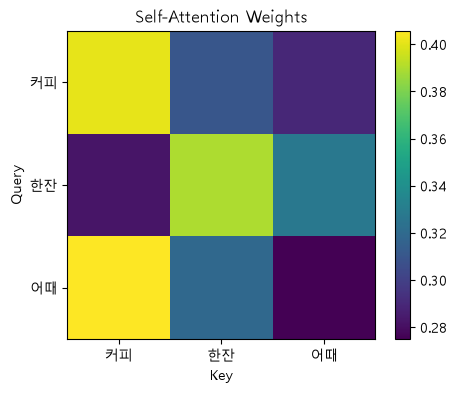

In [106]:
# 밝거나 큰 값을 가진 위치일수록 해당 Query가 해당 Key를 더 많이 참고
weights_np = weights.detach().cpu().numpy()

plt.figure(figsize=(5, 4))
plt.imshow(weights_np)
plt.xticks(range(len(token)), token)
plt.yticks(range(len(token)), token)
plt.xlabel("Key")
plt.ylabel("Query")
plt.title("Self-Attention Weights")
plt.colorbar()
plt.show()

### 2. Transformer Encoder 흐름

```
문장 > Tokenization > Token ID > Token Embedding + Positional Encoding >
Multi-Head Self-Attention > Residual Connection + LayerNorm >
Feed Forward Network(FFN) > Residual Connection + LayerNorm > Encoder 출력
```

### Token ID 만들기

In [108]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(2026)
torch.set_printoptions(precision=3, sci_mode=False)

vocab = {"<PAD>":0, "커피":1, "한잔":2, "어때":3}
tokens = ["커피", "한잔", "어때"]
token_ids = torch.tensor([[1, 2, 3]])

print(tokens)
print(token_ids)
print("shape:", token_ids.shape)

['커피', '한잔', '어때']
tensor([[1, 2, 3]])
shape: torch.Size([1, 3])


### Embedding
정수ID를 nn.Embdding에 넣어 d_model 차원의 실수 벡터로 바꿈
```
d_model=8
커피 > 1 > [8개의 실수]
한잔 > 2 > [8개의 실수]
어때 > 3 > [8개의 실수]
```
> 입력 shape는 (batch, sequence_length)이고, Embedding후에는 (batch, sequence_length, d_model)

In [109]:
vocab_size = len(vocab)
d_model = 8

embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
X = embedding(token_ids)

print(X)
print("shape:", X.shape)  # (batch, sequence_length, d_model

tensor([[[-0.545,  0.219, -1.496,  0.343, -0.192, -0.903,  0.998,  0.036],
         [ 0.244,  0.073,  0.900, -0.805, -0.531,  1.579,  1.451, -1.079],
         [-2.191,  1.543, -0.777,  2.194,  0.926,  0.685, -0.603,  0.600]]],
       grad_fn=<EmbeddingBackward0>)
shape: torch.Size([1, 3, 8])


### Positional Encoding: 순서 정보 넣기
- Self-Attention은 모든 토큰의 관계를 한번에 계산하므로 RNN처럼 처리 순서 자체에서 위치 정보를 얻지 않음
- 입력에 위치 정보를 따로 넣어줌
- Transformer 논문은 고정된 Sin/Cos Positional Encoding을 사용
    - Transformer 입력 = Token Embedding + Positional Encoding

```
커피 Embedding[0.20, -0.40, 0.70, ...]
0번 위치 Position[0.00, 1.00, 0.00, ...]
최종 입력 [0.20, 0.60, 0.70, ...]
```

> 모델이 각 숫자를 "단어 값"과 "위치 값"으로 따로 분리해 읽는 것은 아님. 같은 d_model 공간에서 두 정보를 더해 토큰의 의미 + 위치가 함께 들어있는 표현을 만드는 것
<br>예) "나는 강아지를 좋아해"와 "강아지는 나를 좋아해"처럼 같은 단어가 등장해도 위치와 관계가 달라지면 의미가 달라질 수 있으므로 위치 정보가 중요

### Sin/Cos을 사용하는 이유
- 각 위치마다 여러 주기의 sin/cos 값을 조합하여 서로 다른 패턴을 만듦
- 값은 학습으로 바꾸는 파라키터가 아니라 공식으로 계산한 고정값

### RoPE(Rotary Positional Embedding)  <- 한번 찾아보는게 좋다
- 위치 정보를 입력 임베딩에 단순히 더하지 않음
- Attention을 계산할 때 사용하는  Q와 K에 위치 정보를 반영
- 토큰 위치에 따라서 Q와 K 벡터를 조금씩 회전시키는 방법
- 상대적인 위치 관계

"나는 어제 학교에 갔다"
"나는" "갔다"

### Multi-Head Self-Attention
- 위치 정보가 더해진 X_pos를 Query, Key, Value 모두에 넣어줌
```
query = X_pos
key = X_pos
value = X_pos
```

- 같은 시퀀스 내부에서 서로를 참고하므로 Self-Attention

![멀티헤드어텐션01](./images/멀티헤드어텐션01.png)

![멀티헤드어텐션02](./images/멀티헤드어텐션02.png)

![멀티헤드어텐션03](./images/멀티헤드어텐션03.png)

![멀티헤드어텐션04](./images/멀티헤드어텐션04.png)